In [1]:
#BCS s-wave on 2D square lattice
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

t = 1.0
t1 = 0.0
t2 = 0.0
g = 2.0*t
mu = 0.0

N = 64
k_points = np.linspace(-np.pi, np.pi, N, endpoint=False)
Kx, Ky = np.meshgrid(k_points, k_points)
Total_K_Points = N**2

def gamma(kx, ky):
    gamma = 1.0
    #gamma = np.cos(kx) - np.cos(ky)
    return gamma

def dispersion(kx, ky):
    ek = -2 * t * (np.cos(kx) + np.cos(ky))
    ek -= 4 * t1 * np.cos(kx) * np.cos(ky)
    ek -= 2 * t2 * (np.cos(2*kx) + np.cos(2*ky))
    ek -= mu
    return ek

def gap_equation_summation(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    ek = dispersion(Kx, Ky)
    g_k = gamma(Kx, Ky)
    E_k = np.sqrt(ek**2 + Delta**2*g_k**2 + 1e-6)
    f_k = (g_k**2 * np.tanh(E_k / (2 * T)) / (2 * E_k))
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
def get_Tc():
    def Tc_equation(T):
        return gap_equation_summation(1e-12, T)    
    Tc = fsolve(Tc_equation, 0.5)
    return Tc[0]

Tc = get_Tc()
print('Tc =', Tc, 't')

def solve_gap(T):
    if T >= Tc:
        return 0.0
    gap = fsolve(gap_equation_summation, Tc, args = (T))
    return gap[0]

start_time = time.time()
T_plot = np.linspace(0.01, Tc*1.1, 50)
Delta_plot = [solve_gap(T) for T in T_plot]

T_normalized = T_plot/Tc
Delta_plot = np.array(Delta_plot)
Delta_normalized_s_wave = Delta_plot/Tc

#plt.plot(T_normalized, Delta_normalized_s_wave, marker='o', markersize=3, linestyle='-', color='b')
#plt.xlabel('T/$T_c$')
#plt.ylabel(r'$\Delta/T_c$')
#plt.grid(True, linestyle=':', alpha=0.6)
end_time = time.time()
print('time =', end_time-start_time, 's')

Delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
print(f"2*Delta(0)/Tc = {2 * Delta_0 / Tc:.4f}")
print(f" Delta: {Delta_0:.6f}")

Tc = 0.2055870964673496 t
time = 0.4148275852203369 s
2*Delta(0)/Tc = 3.6586
 Delta: 0.376083


In [2]:
#BCS d-wave on 2D square lattice
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

t = 1.0
t1 = 0.0
t2 = 0.0
g = 2.0*t
mu = 0.0

N = 64
k_points = np.linspace(-np.pi, np.pi, N, endpoint=False)
Kx, Ky = np.meshgrid(k_points, k_points)
Total_K_Points = N**2

def gamma(kx, ky):
    #gamma = 1.0
    gamma = np.cos(kx) - np.cos(ky)
    return gamma

def dispersion(kx, ky):
    ek = -2 * t * (np.cos(kx) + np.cos(ky))
    ek -= 4 * t1 * np.cos(kx) * np.cos(ky)
    ek -= 2 * t2 * (np.cos(2*kx) + np.cos(2*ky))
    ek -= mu
    return ek

def gap_equation_summation(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    ek = dispersion(Kx, Ky)
    g_k = gamma(Kx, Ky)
    E_k = np.sqrt(ek**2 + Delta**2*g_k**2 + 1e-6)
    f_k = (g_k**2 * np.tanh(E_k / (2 * T)) / (2 * E_k))
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
def get_Tc():
    def Tc_equation(T):
        return gap_equation_summation(1e-12, T)    
    Tc = fsolve(Tc_equation, 0.5)
    return Tc[0]

Tc = get_Tc()
print('Tc =', Tc, 't')

def solve_gap(T):
    if T >= Tc:
        return 0.0
    gap = fsolve(gap_equation_summation, Tc, args = (T))
    return gap[0]

start_time = time.time()
T_plot = np.linspace(0.01, Tc*1.1, 50)
Delta_plot = [solve_gap(T) for T in T_plot]

T_normalized = T_plot/Tc
Delta_plot = np.array(Delta_plot)
Delta_normalized_s_wave = Delta_plot/Tc

#plt.plot(T_normalized, Delta_normalized_s_wave, marker='o', markersize=3, linestyle='-', color='b')
#plt.xlabel('T/$T_c$')
#plt.ylabel(r'$\Delta/T_c$')
#plt.grid(True, linestyle=':', alpha=0.6)
end_time = time.time()
print('time =', end_time-start_time, 's')

Delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
print(f"2*Delta(0)/Tc = {2 * Delta_0 / Tc:.4f}")
print(f" Delta: {Delta_0:.6f}")

Tc = 0.399731476082245 t
time = 0.3953135013580322 s
2*Delta(0)/Tc = 2.4100
 Delta: 0.481678


C:\Users\fishb\AppData\Local\Temp\ipykernel_4876\590891456.py:43: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  Tc = fsolve(Tc_equation, 0.5)


Tc = 1.9151660543251722e-05 t


C:\Users\fishb\AppData\Local\Temp\ipykernel_4876\590891456.py:55: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]


2*Delta(0)/Tc = 50301.4060
 Delta: 0.481678
mu = 0.7
delta = 0.18124444632750134
mu = 0.633673469387755
delta = 0.19872879044813638
mu = 0.5673469387755101
delta = 0.21646838445671834
mu = 0.5010204081632652
delta = 0.2343831800148557
mu = 0.43469387755102035
delta = 0.2523060307119557
mu = 0.36836734693877543
delta = 0.2701381279294797
mu = 0.30204081632653057
delta = 0.2877804540258766
mu = 0.23571428571428565
delta = 0.30509979979967017
mu = 0.16938775510204074
delta = 0.3220176754564768
mu = 0.10306122448979582
delta = 0.3384432066748272
mu = 0.036734693877550906
delta = 0.35427940006791336
mu = -0.02959183673469401
delta = 0.369465023408431
mu = -0.09591836734693882
delta = 0.3839245874393887
mu = -0.16224489795918373
delta = 0.397590912100667
mu = -0.22857142857142865
delta = 0.41041584256498687
mu = -0.29489795918367356
delta = 0.4223366303202269
mu = -0.3612244897959185
delta = 0.43330766358492084
mu = -0.4275510204081634
delta = 0.4432868992477055
mu = -0.4938775510204083
delt

C:\Users\fishb\AppData\Local\Temp\ipykernel_4876\590891456.py:64: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]


mu = -2.417346938775511
delta = -0.0018960143937819206
mu = -2.483673469387755
delta = -0.0018960143937819202
mu = -2.55
delta = -0.0018960143937819206


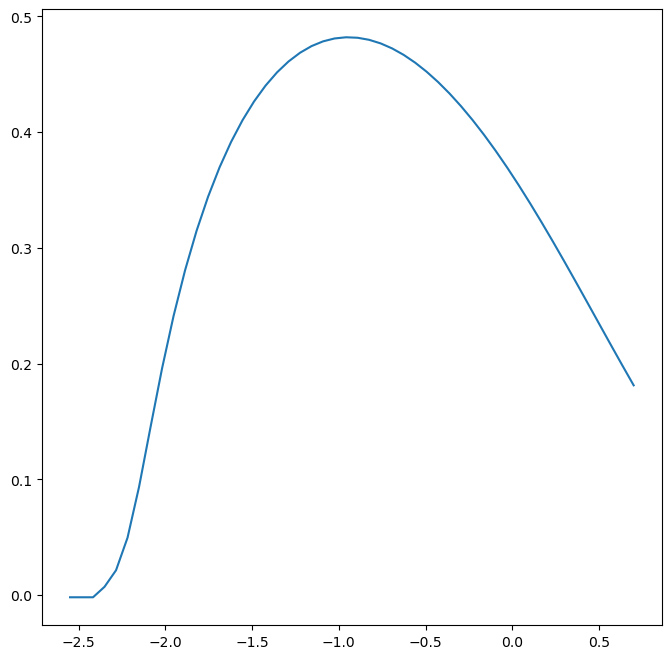

In [10]:
#BCS d-wave on 2D square lattice delta_0 vs mu
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

t = 1.0
t1 = -0.2
t2 = 0.1
g = 2.0

N = 128*2
k_points = np.linspace(-np.pi, np.pi, N, endpoint=False)
Kx, Ky = np.meshgrid(k_points, k_points)
Total_K_Points = N**2

def gamma(kx, ky):
    #gamma = 1.0
    gamma = np.cos(kx) - np.cos(ky)
    return gamma

def dispersion(kx, ky):
    ek = -2 * t * (np.cos(kx) + np.cos(ky))
    ek -= 4 * t1 * np.cos(kx) * np.cos(ky)
    ek -= 2 * t2 * (np.cos(2*kx) + np.cos(2*ky))
    ek -= mu
    return ek

def gap_equation_summation(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    ek = dispersion(Kx, Ky)
    g_k = gamma(Kx, Ky)
    E_k = np.sqrt(ek**2 + Delta**2*g_k**2 + 1e-6)
    f_k = (g_k**2 * np.tanh(E_k / (2 * T)) / (2 * E_k))
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
def get_Tc():
    def Tc_equation(T):
        return gap_equation_summation(1e-12, T)    
    Tc = fsolve(Tc_equation, 0.5)
    return Tc[0]

Tc = get_Tc()
print('Tc =', Tc, 't')

def solve_gap(T):
    if T >= Tc:
        return 0.0
    gap = fsolve(gap_equation_summation, Tc, args = (T))
    return gap[0]

delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
print(f"2*Delta(0)/Tc = {2 * Delta_0 / Tc:.4f}")
print(f" Delta: {Delta_0:.6f}")


mu_list = np.linspace(0.70, -2.55, 50)  #U=2.0

delta_results = []
for mu in mu_list:
    delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
    delta_results.append(delta_0)
    print('mu =',mu)
    print('delta =',delta_0)

plt.figure(figsize=(8, 8))
plt.plot(mu_list, delta_results)

C:\Users\fishb\AppData\Local\Temp\ipykernel_4876\2826361278.py:43: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  Tc = fsolve(Tc_equation, 0.5)


Tc = 1.9151660543251722e-05 t
2*Delta(0)/Tc = 50301.4060
 Delta: 0.481678


C:\Users\fishb\AppData\Local\Temp\ipykernel_4876\2826361278.py:55: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]


mu = 0.7
Tc = 0.12568384585859158 t
mu = 0.633673469387755
Tc = 0.1404398473589331 t
mu = 0.5673469387755101
Tc = 0.15586423738921876 t
mu = 0.5010204081632652
Tc = 0.17184997498965177 t
mu = 0.43469387755102035
Tc = 0.18826670684631616 t
mu = 0.36836734693877543
Tc = 0.2049594020970965 t
mu = 0.30204081632653057
Tc = 0.22175033698408622 t
mu = 0.23571428571428565
Tc = 0.2384459860781896 t
mu = 0.16938775510204074
Tc = 0.2548484503280542 t
mu = 0.10306122448979582
Tc = 0.27076885815046287 t
mu = 0.036734693877550906
Tc = 0.2860392221633821 t
mu = -0.02959183673469401
Tc = 0.30052007311552964 t
mu = -0.09591836734693882
Tc = 0.3141030471698028 t
mu = -0.16224489795918373
Tc = 0.32670925199033907 t
mu = -0.22857142857142865
Tc = 0.33828500645384485 t
mu = -0.29489795918367356
Tc = 0.34879650328929546 t
mu = -0.3612244897959185
Tc = 0.3582244906387371 t
mu = -0.4275510204081634
Tc = 0.366559564845936 t
mu = -0.4938775510204083
Tc = 0.3737982861628625 t
mu = -0.5602040816326532
Tc = 0.3799

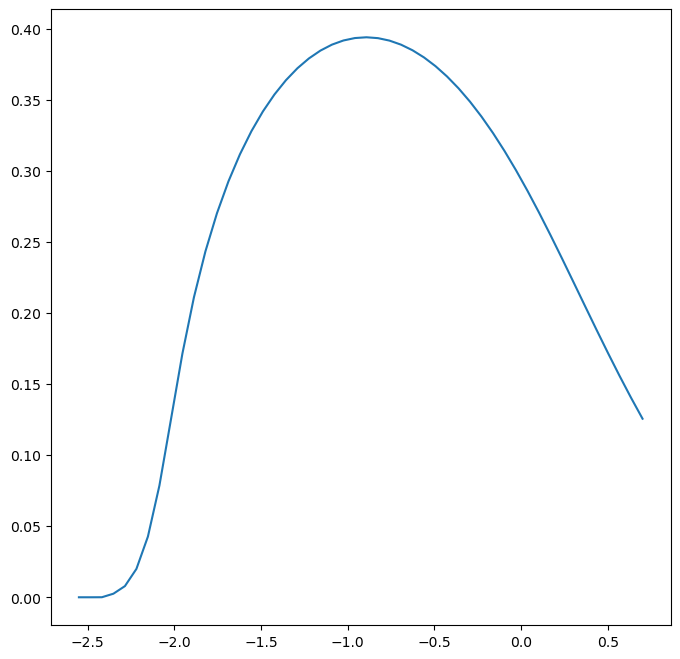

In [11]:
#BCS d-wave on 2D square lattice Tc vs mu
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

t = 1.0
t1 = -0.2
t2 = 0.1
g = 2.0

N = 128*2
k_points = np.linspace(-np.pi, np.pi, N, endpoint=False)
Kx, Ky = np.meshgrid(k_points, k_points)
Total_K_Points = N**2

def gamma(kx, ky):
    #gamma = 1.0
    gamma = np.cos(kx) - np.cos(ky)
    return gamma

def dispersion(kx, ky):
    ek = -2 * t * (np.cos(kx) + np.cos(ky))
    ek -= 4 * t1 * np.cos(kx) * np.cos(ky)
    ek -= 2 * t2 * (np.cos(2*kx) + np.cos(2*ky))
    ek -= mu
    return ek

def gap_equation_summation(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    ek = dispersion(Kx, Ky)
    g_k = gamma(Kx, Ky)
    E_k = np.sqrt(ek**2 + Delta**2*g_k**2 + 1e-6)
    f_k = (g_k**2 * np.tanh(E_k / (2 * T)) / (2 * E_k))
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
def get_Tc():
    def Tc_equation(T):
        return gap_equation_summation(1e-12, T)    
    Tc = fsolve(Tc_equation, 0.5)
    return Tc[0]

Tc = get_Tc()
print('Tc =', Tc, 't')

def solve_gap(T):
    if T >= Tc:
        return 0.0
    gap = fsolve(gap_equation_summation, Tc, args = (T))
    return gap[0]

delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
print(f"2*Delta(0)/Tc = {2 * Delta_0 / Tc:.4f}")
print(f" Delta: {Delta_0:.6f}")


mu_list = np.linspace(0.70, -2.55, 50)  #U=2.0

Tc_results = []
for mu in mu_list:
    Tc = get_Tc()
    print('mu =',mu)
    print('Tc =', Tc, 't')
    Tc_results.append(Tc)

plt.figure(figsize=(8, 8))
plt.plot(mu_list, Tc_results)

array([   2.88413272,    2.83009123,    2.77765301,    2.72776508,
          2.68030429,    2.63601596,    2.59553566,    2.55906845,
          2.52713073,    2.49986803,    2.47713861,    2.45883757,
          2.44457729,    2.43391278,    2.42645009,    2.42167927,
          2.4191962 ,    2.41863501,    2.41959358,    2.42181766,
          2.42503428,    2.42899983,    2.43355746,    2.43852145,
          2.44378011,    2.44920928,    2.45472927,    2.46028563,
          2.4658105 ,    2.47132135,    2.47681468,    2.48240106,
          2.48819906,    2.49456743,    2.50203063,    2.51167055,
          2.52542002,    2.54720796,    2.58532866,    2.65833257,
          2.81056305,    3.1323407 ,    3.69175983,    4.37254924,
          4.96449991,    5.44873013,    5.6497608 ,  -72.78335792,
       -205.66084476, -198.        ])

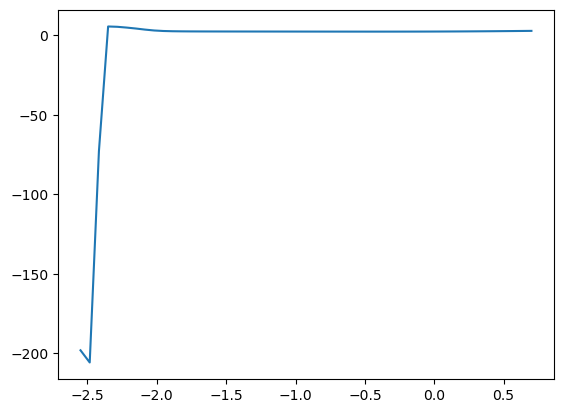

In [18]:
ratio = 2*np.array(delta_results)/np.array(Tc_results)
plt.plot(mu_list, ratio)
ratio